# ClassTran two-index contemporaneous characterization

This notebook characterizes the study area using the temporal flexibility index
and geographical flexibility index constructed in
`data_analysis_pattern_Classtran_two_indexes.ipynb`.

The unit of analysis is the demand segment:

$$
s = (	ext{Purpose},\ 	ext{1.5-mile origin zone},\ 	ext{weekday}).
$$

The analysis is contemporaneous: flexibility and trip outcomes come from the
same July 2022-June 2023 period. Therefore, all outcome results are descriptive
associations, not causal effects. Completion and cancellation are used only for
characterization; they do not enter any flexibility or demand-management score.


## Analysis choices

- Reuse the same raw workbook, 1.5-mile grid, 30-minute promised-pickup bins,
  120-minute shift horizon, and reliability filter as the two-index notebook.
- Reliable means at least 10 trips observed on at least 3 distinct service dates.
- Workshop, Employment, Education, and Medical remain policy-rigid; their two
  published indices are NA and they are excluded from scored-index comparisons.
- The primary outcome denominator contains trips whose status is recognized as
  completed or cancelled. Other statuses are reported separately rather than
  silently assigned to either outcome.
- Segment-level group rates are trip-weighted: total completed trips divided by
  total completed-plus-cancelled trips in the group.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/classTran-matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

PROJECT_DIR = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-")
DATA_PATH = PROJECT_DIR / "Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx"
SHEET_NAME = "SMART Trip Data"

GRID_MILES = 1.5
TIME_BIN_MINUTES = 30
SHIFT_HORIZON_MINUTES = 120
MIN_SEGMENT_TRIPS = 10
MIN_SEGMENT_SERVICE_DAYS = 3

sys.path.insert(0, str(PROJECT_DIR))
from two_index_flexibility import RIGID_PURPOSES, run_two_index_analysis

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Load the same trip data and reconstruct the two indices

In [2]:
source_columns = [
    "Trip ID", "Trip Date", "Trip Status", "Cancel Type", "Purpose",
    "Promised Pick-up Time", "Pick-up Latitude", "Pick-up Longitude",
    "Drop-off Latitude", "Drop-off Longitude",
]

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, usecols=source_columns)
results = run_two_index_analysis(
    df_raw,
    grid_miles=GRID_MILES,
    time_bin_minutes=TIME_BIN_MINUTES,
    shift_horizon_minutes=SHIFT_HORIZON_MINUTES,
    min_segment_trips=MIN_SEGMENT_TRIPS,
    min_segment_service_days=MIN_SEGMENT_SERVICE_DAYS,
)

analysis_frame = results["analysis_frame"]
segment_summary = results["segment_summary"].copy()
metadata = results["metadata"]

print(f"Raw rows: {len(df_raw):,}")
print(f"Usable trips for index construction: {len(analysis_frame):,}")
print(f"Demand segments: {len(segment_summary):,}")


Raw rows: 121,281
Usable trips for index construction: 121,281
Demand segments: 3,400


## 2. Attach trip outcomes to the same demand segments

Outcome fields are aligned by original workbook row. This is safer than joining
only on `Trip ID` if an identifier appears more than once. Status labels are
normalized to lower case. A status beginning with `comp` is completed and a
status beginning with `cancel` is cancelled; every other status is retained as
`other` and excluded from the primary binary-outcome denominator.


In [3]:
outcome_trips = analysis_frame[["Trip ID", "segment_id"]].copy()
outcome_trips[["Trip Status", "Cancel Type"]] = df_raw.loc[
    outcome_trips.index, ["Trip Status", "Cancel Type"]
]

outcome_trips["status_normalized"] = (
    outcome_trips["Trip Status"].astype("string").str.strip().str.lower()
)
outcome_trips["is_completed"] = outcome_trips["status_normalized"].str.startswith(
    "comp", na=False
)
outcome_trips["is_cancelled"] = outcome_trips["status_normalized"].str.startswith(
    "cancel", na=False
)
outcome_trips["is_other_status"] = ~(
    outcome_trips["is_completed"] | outcome_trips["is_cancelled"]
)

status_counts = (
    outcome_trips.groupby("status_normalized", dropna=False)
    .size().rename("trips").reset_index().sort_values("trips", ascending=False)
)
display(status_counts)

segment_outcomes = (
    outcome_trips.groupby("segment_id", observed=True)
    .agg(
        status_trips=("Trip ID", "count"),
        completed_trips=("is_completed", "sum"),
        cancelled_trips=("is_cancelled", "sum"),
        other_status_trips=("is_other_status", "sum"),
    )
    .reset_index()
)
segment_outcomes["outcome_trips"] = (
    segment_outcomes["completed_trips"] + segment_outcomes["cancelled_trips"]
)
segment_outcomes["completion_rate"] = (
    segment_outcomes["completed_trips"] / segment_outcomes["outcome_trips"]
)
segment_outcomes["cancellation_rate"] = (
    segment_outcomes["cancelled_trips"] / segment_outcomes["outcome_trips"]
)

characterization = segment_summary.merge(segment_outcomes, on="segment_id", how="left")
scored = characterization.loc[
    characterization["temporal_flexibility_index"].notna()
    & characterization["geographical_flexibility_index"].notna()
    & characterization["outcome_trips"].gt(0)
].copy()

assert np.allclose(
    scored["completion_rate"] + scored["cancellation_rate"], 1.0
)
print(f"Scored segments with binary outcomes: {len(scored):,}")


,status_normalized,trips
1,comp,63841
0,cancel,54121
2,noshow,3319


Scored segments with binary outcomes: 745


## 3. Coverage and score availability

In [4]:
coverage = pd.DataFrame({
    "stage": [
        "All demand segments",
        "Reliable segments",
        "Reliable policy-rigid segments",
        "Published temporal scores",
        "Published geographical scores",
        "Scored segments with binary outcomes",
    ],
    "segments": [
        len(characterization),
        int(characterization["meets_reliability_filter"].sum()),
        int((characterization["meets_reliability_filter"] & ~characterization["policy_flexible"]).sum()),
        int(characterization["temporal_flexibility_index"].notna().sum()),
        int(characterization["geographical_flexibility_index"].notna().sum()),
        len(scored),
    ],
})
display(coverage)

purpose_coverage = (
    characterization.groupby(["Purpose", "policy_flexible"], observed=True)
    .agg(
        segments=("segment_id", "size"),
        trips=("trips", "sum"),
        reliable_segments=("meets_reliability_filter", "sum"),
        temporal_scores=("temporal_flexibility_index", "count"),
        geographical_scores=("geographical_flexibility_index", "count"),
    )
    .reset_index().sort_values("trips", ascending=False)
)
display(purpose_coverage)


,stage,segments
0,All demand segments,3400
1,Reliable segments,1527
2,Reliable policy-rigid segments,782
3,Published temporal scores,745
4,Published geographical scores,745
5,Scored segments with binary outcomes,745


,Purpose,policy_flexible,segments,trips,reliable_segments,temporal_scores,geographical_scores
5,Nutrition,True,546,64285,433,433,433
3,Medical,False,1065,17015,453,0,0
2,Employment,False,354,13619,220,0,0
0,Dialysis,True,260,13186,157,157,157
10,Workshop,False,134,5511,71,0,0
6,Personal,True,428,2689,76,76,76
8,Shopping,True,330,2192,56,56,56
1,Education,False,116,1526,38,0,0
7,Recreation,True,135,1001,23,23,23
4,Missing / Unknown,False,25,245,0,0,0


## 4. Marginal distributions of the two indices

,index,n,mean,std,minimum,q25,median,q75,maximum,zero_share
0,Temporal flexibility (T_s),745,0.1567,0.1484,0.0000,0.0411,0.1237,0.2214,0.8500,10.9%
1,Geographical flexibility (G_s),745,0.2092,0.2934,0.0000,0.0000,0.0000,0.4942,0.9019,57.7%


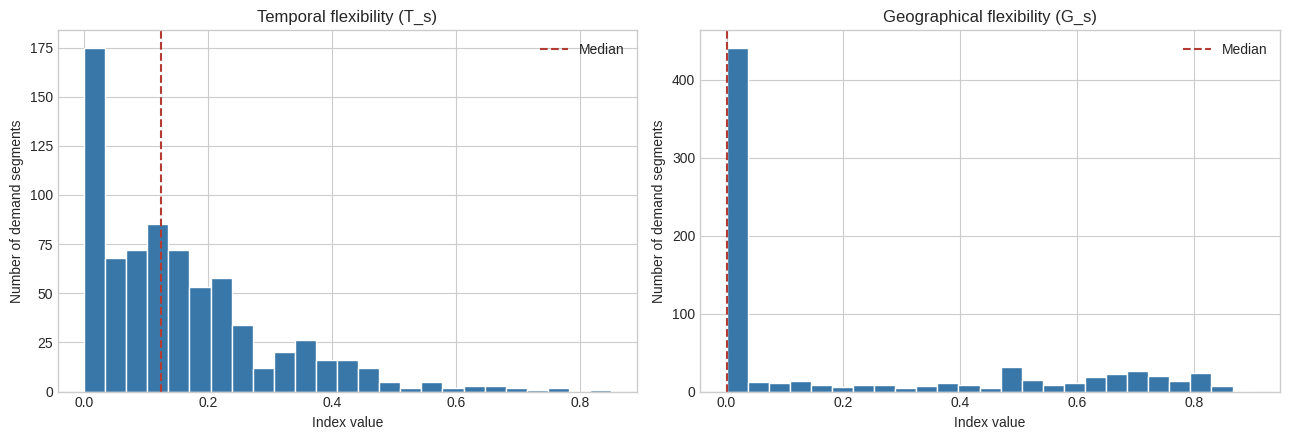

In [5]:
index_columns = {
    "Temporal flexibility (T_s)": "temporal_flexibility_index",
    "Geographical flexibility (G_s)": "geographical_flexibility_index",
}

distribution_rows = []
for label, column in index_columns.items():
    values = scored[column].dropna()
    distribution_rows.append({
        "index": label,
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(),
        "minimum": values.min(),
        "q25": values.quantile(0.25),
        "median": values.median(),
        "q75": values.quantile(0.75),
        "maximum": values.max(),
        "zero_share": values.eq(0).mean(),
    })
index_distribution = pd.DataFrame(distribution_rows)
display(index_distribution.style.format({
    "mean": "{:.4f}", "std": "{:.4f}", "minimum": "{:.4f}",
    "q25": "{:.4f}", "median": "{:.4f}", "q75": "{:.4f}",
    "maximum": "{:.4f}", "zero_share": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (label, column) in zip(axes, index_columns.items()):
    ax.hist(scored[column], bins=25, color="#3977a8", edgecolor="white")
    ax.axvline(scored[column].median(), color="#b33b32", linestyle="--", label="Median")
    ax.set(title=label, xlabel="Index value", ylabel="Number of demand segments")
    ax.legend()
plt.tight_layout()
plt.show()


,Purpose,segments,trips,temporal_mean,temporal_median,geographical_mean,geographical_median,single_destination_share
1,Nutrition,433,63854,0.1069,0.0992,0.1465,0.0000,71.8%
0,Dialysis,157,12855,0.1407,0.0962,0.1747,0.0000,56.1%
2,Personal,76,1483,0.3476,0.3298,0.4290,0.4589,11.8%
4,Shopping,56,1189,0.3260,0.3209,0.5019,0.5993,14.3%
3,Recreation,23,561,0.1628,0.1364,0.1871,0.0000,60.9%


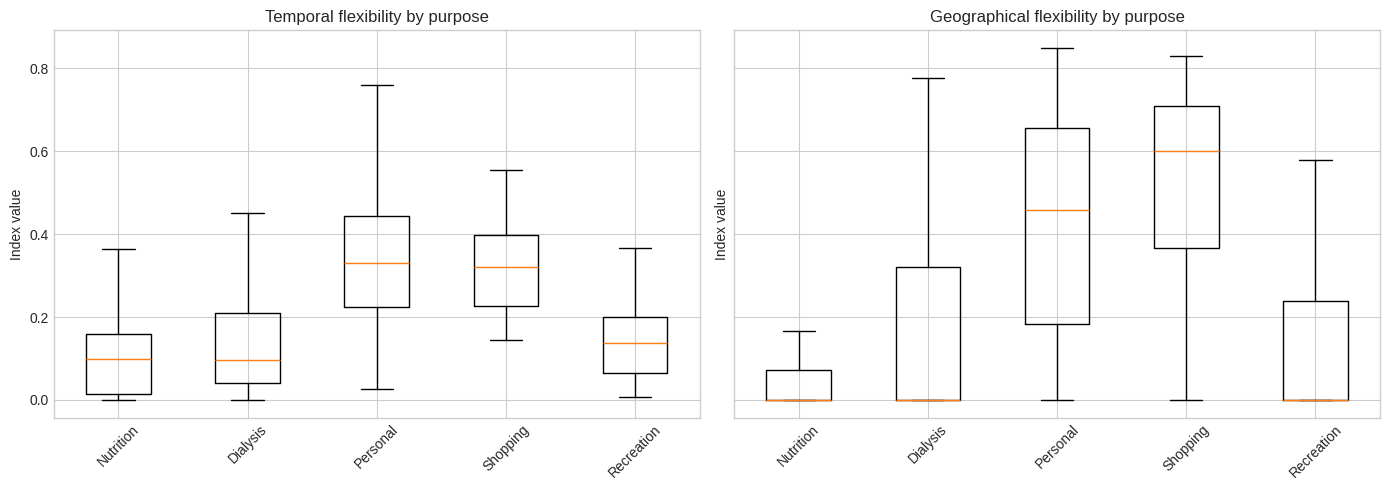

In [6]:
purpose_distribution = (
    scored.groupby("Purpose", observed=True)
    .agg(
        segments=("segment_id", "size"),
        trips=("trips", "sum"),
        temporal_mean=("temporal_flexibility_index", "mean"),
        temporal_median=("temporal_flexibility_index", "median"),
        geographical_mean=("geographical_flexibility_index", "mean"),
        geographical_median=("geographical_flexibility_index", "median"),
        single_destination_share=("geographical_flexibility_index", lambda x: x.eq(0).mean()),
    )
    .reset_index().sort_values("trips", ascending=False)
)
display(purpose_distribution.style.format({
    "temporal_mean": "{:.4f}", "temporal_median": "{:.4f}",
    "geographical_mean": "{:.4f}", "geographical_median": "{:.4f}",
    "single_destination_share": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
purpose_order = purpose_distribution["Purpose"].tolist()
for ax, column, title in [
    (axes[0], "temporal_flexibility_index", "Temporal flexibility by purpose"),
    (axes[1], "geographical_flexibility_index", "Geographical flexibility by purpose"),
]:
    data = [scored.loc[scored["Purpose"].eq(p), column].to_numpy() for p in purpose_order]
    ax.boxplot(data, labels=purpose_order, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Index value")
plt.tight_layout()
plt.show()


## 5. Joint temporal-geographical characterization

The scatterplot keeps both indices continuous. For an interpretable operational
typology, temporal flexibility is split at its scored-segment median, while
geographical flexibility distinguishes a single observed destination ($G_s=0$)
from observed destination diversity ($G_s>0$).


Spearman T_s vs G_s: rho=0.512, p=5.25e-51, n=745


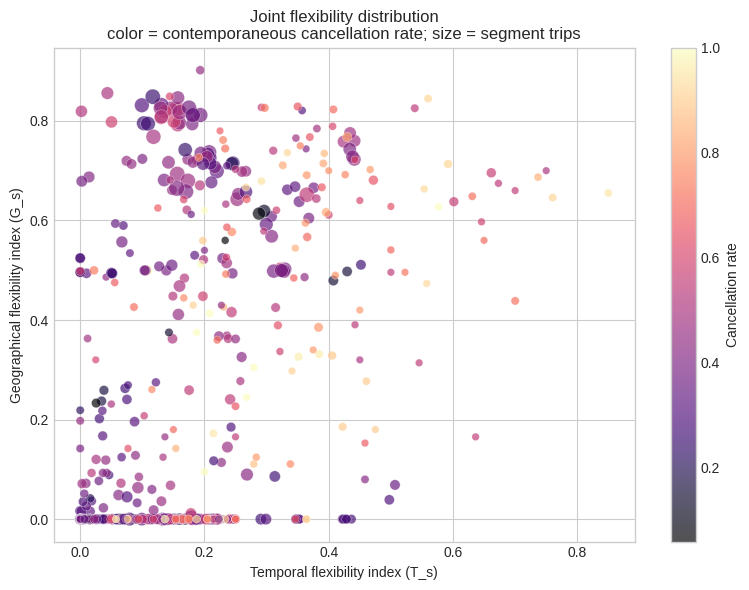

,flexibility_type,segments,trips,outcome_trips,completed_trips,cancelled_trips,temporal_mean,geographical_mean,weighted_completion_rate,weighted_cancellation_rate
0,Higher temporal flexibility / Destination diversity observed,234,40460,39647,22408,17239,0.3069,0.5524,56.5%,43.5%
1,Higher temporal flexibility / Single destination observed,139,12195,11633,6773,4860,0.1984,0.0000,58.2%,41.8%
2,Lower temporal flexibility / Destination diversity observed,81,10259,9972,6325,3647,0.0509,0.3286,63.4%,36.6%
3,Lower temporal flexibility / Single destination observed,291,17028,16188,10070,6118,0.0455,0.0000,62.2%,37.8%


In [7]:
rho_tg, p_tg = spearmanr(
    scored["temporal_flexibility_index"],
    scored["geographical_flexibility_index"],
)
print(f"Spearman T_s vs G_s: rho={rho_tg:.3f}, p={p_tg:.4g}, n={len(scored):,}")

fig, ax = plt.subplots(figsize=(8, 6))
sizes = 18 + 110 * np.sqrt(scored["trips"] / scored["trips"].max())
scatter = ax.scatter(
    scored["temporal_flexibility_index"],
    scored["geographical_flexibility_index"],
    s=sizes, c=scored["cancellation_rate"], cmap="magma", alpha=0.68,
    edgecolor="white", linewidth=0.3,
)
ax.set(
    xlabel="Temporal flexibility index (T_s)",
    ylabel="Geographical flexibility index (G_s)",
    title="Joint flexibility distribution\ncolor = contemporaneous cancellation rate; size = segment trips",
)
fig.colorbar(scatter, ax=ax, label="Cancellation rate")
plt.tight_layout()
plt.show()

temporal_median = scored["temporal_flexibility_index"].median()
scored["temporal_class"] = np.where(
    scored["temporal_flexibility_index"].ge(temporal_median),
    "Higher temporal flexibility", "Lower temporal flexibility",
)
scored["geographical_class"] = np.where(
    scored["geographical_flexibility_index"].gt(0),
    "Destination diversity observed", "Single destination observed",
)
scored["flexibility_type"] = (
    scored["temporal_class"] + " / " + scored["geographical_class"]
)

def grouped_outcome_summary(frame, group_columns):
    result = (
        frame.groupby(group_columns, observed=True)
        .agg(
            segments=("segment_id", "size"),
            trips=("trips", "sum"),
            outcome_trips=("outcome_trips", "sum"),
            completed_trips=("completed_trips", "sum"),
            cancelled_trips=("cancelled_trips", "sum"),
            temporal_mean=("temporal_flexibility_index", "mean"),
            geographical_mean=("geographical_flexibility_index", "mean"),
        )
        .reset_index()
    )
    result["weighted_completion_rate"] = result["completed_trips"] / result["outcome_trips"]
    result["weighted_cancellation_rate"] = result["cancelled_trips"] / result["outcome_trips"]
    return result

flexibility_typology = grouped_outcome_summary(scored, ["flexibility_type"])
display(flexibility_typology.style.format({
    "temporal_mean": "{:.4f}", "geographical_mean": "{:.4f}",
    "weighted_completion_rate": "{:.1%}", "weighted_cancellation_rate": "{:.1%}",
}))


## 6. Relationships with completion and cancellation

,index,outcome,segments,spearman_rho,p_value
0,Temporal flexibility (T_s),Completion rate,745,-0.376,2.01e-26
1,Temporal flexibility (T_s),Cancellation rate,745,0.376,2.01e-26
2,Geographical flexibility (G_s),Completion rate,745,-0.232,1.47e-10
3,Geographical flexibility (G_s),Cancellation rate,745,0.232,1.47e-10


,temporal_quartile,segments,trips,outcome_trips,completed_trips,cancelled_trips,temporal_mean,geographical_mean,weighted_completion_rate,weighted_cancellation_rate
0,Q1 lowest,187,11147,10736,6733,4003,0.0096,0.0491,62.7%,37.3%
1,Q2,186,16235,15519,9723,5796,0.0844,0.0937,62.7%,37.3%
2,Q3,186,34684,33737,19172,14565,0.1691,0.2528,56.8%,43.2%
3,Q4 highest,186,17876,17448,9948,7500,0.3646,0.4422,57.0%,43.0%


,geographical_group,segments,trips,outcome_trips,completed_trips,cancelled_trips,temporal_mean,geographical_mean,weighted_completion_rate,weighted_cancellation_rate
0,G=0 single destination,430,29223,27821,16843,10978,0.0950,0.0000,60.5%,39.5%
1,G>0 higher,105,30394,29923,17266,12657,0.2648,0.7511,57.7%,42.3%
2,G>0 lower,105,7099,6766,3917,2849,0.1786,0.1868,57.9%,42.1%
3,G>0 middle,105,13226,12930,7550,5380,0.2799,0.5468,58.4%,41.6%


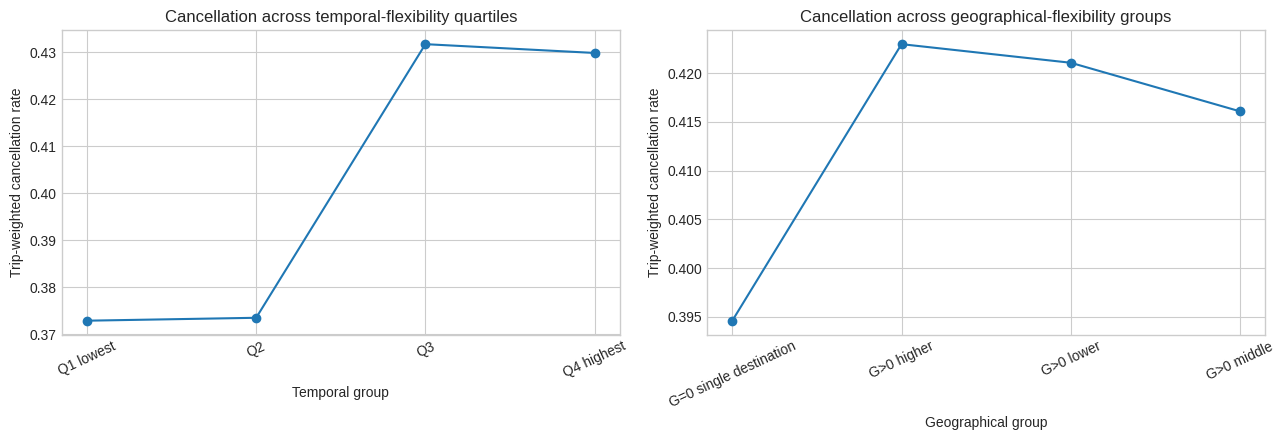

In [8]:
correlation_rows = []
for index_label, index_column in index_columns.items():
    for outcome_label, outcome_column in [
        ("Completion rate", "completion_rate"),
        ("Cancellation rate", "cancellation_rate"),
    ]:
        valid = scored[[index_column, outcome_column]].dropna()
        rho, p_value = spearmanr(valid[index_column], valid[outcome_column])
        correlation_rows.append({
            "index": index_label,
            "outcome": outcome_label,
            "segments": len(valid),
            "spearman_rho": rho,
            "p_value": p_value,
        })
correlations = pd.DataFrame(correlation_rows)
display(correlations.style.format({"spearman_rho": "{:.3f}", "p_value": "{:.4g}"}))

scored["temporal_quartile"] = pd.qcut(
    scored["temporal_flexibility_index"],
    q=4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"], duplicates="drop",
)

positive_geo = scored["geographical_flexibility_index"].gt(0)
scored["geographical_group"] = "G=0 single destination"
if positive_geo.sum() >= 3:
    scored.loc[positive_geo, "geographical_group"] = pd.qcut(
        scored.loc[positive_geo, "geographical_flexibility_index"],
        q=3, labels=["G>0 lower", "G>0 middle", "G>0 higher"], duplicates="drop",
    ).astype("string")

temporal_bins = grouped_outcome_summary(scored, ["temporal_quartile"])
geographical_bins = grouped_outcome_summary(scored, ["geographical_group"])
display(temporal_bins.style.format({
    "temporal_mean": "{:.4f}", "geographical_mean": "{:.4f}",
    "weighted_completion_rate": "{:.1%}", "weighted_cancellation_rate": "{:.1%}",
}))
display(geographical_bins.style.format({
    "temporal_mean": "{:.4f}", "geographical_mean": "{:.4f}",
    "weighted_completion_rate": "{:.1%}", "weighted_cancellation_rate": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(temporal_bins["temporal_quartile"].astype(str),
             temporal_bins["weighted_cancellation_rate"], marker="o")
axes[0].set(title="Cancellation across temporal-flexibility quartiles",
            xlabel="Temporal group", ylabel="Trip-weighted cancellation rate")
axes[0].tick_params(axis="x", rotation=25)
axes[1].plot(geographical_bins["geographical_group"].astype(str),
             geographical_bins["weighted_cancellation_rate"], marker="o")
axes[1].set(title="Cancellation across geographical-flexibility groups",
            xlabel="Geographical group", ylabel="Trip-weighted cancellation rate")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


In [9]:
purpose_outcomes = grouped_outcome_summary(scored, ["Purpose"])
weekday_outcomes = grouped_outcome_summary(scored, ["weekday"])
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_outcomes["weekday"] = pd.Categorical(
    weekday_outcomes["weekday"], categories=weekday_order, ordered=True
)
weekday_outcomes = weekday_outcomes.sort_values("weekday")

print("Purpose-level characterization")
display(purpose_outcomes.style.format({
    "temporal_mean": "{:.4f}", "geographical_mean": "{:.4f}",
    "weighted_completion_rate": "{:.1%}", "weighted_cancellation_rate": "{:.1%}",
}))
print("Weekday-level characterization")
display(weekday_outcomes.style.format({
    "temporal_mean": "{:.4f}", "geographical_mean": "{:.4f}",
    "weighted_completion_rate": "{:.1%}", "weighted_cancellation_rate": "{:.1%}",
}))


Purpose-level characterization


,Purpose,segments,trips,outcome_trips,completed_trips,cancelled_trips,temporal_mean,geographical_mean,weighted_completion_rate,weighted_cancellation_rate
0,Dialysis,157,12855,12605,7768,4837,0.1407,0.1747,61.6%,38.4%
1,Nutrition,433,63854,61658,36773,24885,0.1069,0.1465,59.6%,40.4%
2,Personal,76,1483,1459,450,1009,0.3476,0.4290,30.8%,69.2%
3,Recreation,23,561,542,234,308,0.1628,0.1871,43.2%,56.8%
4,Shopping,56,1189,1176,351,825,0.3260,0.5019,29.8%,70.2%


Weekday-level characterization


,weekday,segments,trips,outcome_trips,completed_trips,cancelled_trips,temporal_mean,geographical_mean,weighted_completion_rate,weighted_cancellation_rate
1,Monday,142,15984,15483,8526,6957,0.1362,0.1906,55.1%,44.9%
3,Tuesday,133,14211,13696,8581,5115,0.1640,0.2174,62.7%,37.3%
4,Wednesday,160,18442,17929,11133,6796,0.1573,0.2082,62.1%,37.9%
2,Thursday,143,14128,13638,8008,5630,0.1538,0.2087,58.7%,41.3%
0,Friday,167,17177,16694,9328,7366,0.1704,0.2202,55.9%,44.1%


### Within-purpose association check

The overall index-outcome correlation can reflect differences in the mix of trip
purposes. The following table therefore repeats the Spearman calculation within
each purpose that has enough scored segments. This is a stratified descriptive
check, not a causal or predictive model.


In [10]:
within_purpose_rows = []
for purpose, group in scored.groupby("Purpose", observed=True):
    if len(group) < 10:
        continue
    for index_label, index_column in index_columns.items():
        if group[index_column].nunique() < 2 or group["cancellation_rate"].nunique() < 2:
            rho, p_value = np.nan, np.nan
        else:
            rho, p_value = spearmanr(group[index_column], group["cancellation_rate"])
        within_purpose_rows.append({
            "Purpose": purpose,
            "index": index_label,
            "segments": len(group),
            "spearman_rho_with_cancellation": rho,
            "p_value": p_value,
        })
within_purpose_correlations = pd.DataFrame(within_purpose_rows)
display(within_purpose_correlations.style.format({
    "spearman_rho_with_cancellation": "{:.3f}", "p_value": "{:.4g}"
}))


,Purpose,index,segments,spearman_rho_with_cancellation,p_value
0,Dialysis,Temporal flexibility (T_s),157,0.163,0.04154
1,Dialysis,Geographical flexibility (G_s),157,0.264,0.0008342
2,Nutrition,Temporal flexibility (T_s),433,0.172,0.0003115
3,Nutrition,Geographical flexibility (G_s),433,-0.001,0.9827
4,Personal,Temporal flexibility (T_s),76,0.270,0.01839
5,Personal,Geographical flexibility (G_s),76,0.011,0.9281
6,Recreation,Temporal flexibility (T_s),23,0.178,0.4164
7,Recreation,Geographical flexibility (G_s),23,-0.362,0.08933
8,Shopping,Temporal flexibility (T_s),56,-0.042,0.7567
9,Shopping,Geographical flexibility (G_s),56,-0.173,0.2011


## 7. Origin-grid characterization

Each origin zone is summarized across its scored purpose-weekday segments.
Index means are weighted by segment trip counts. Marker size represents scored
trip volume, so a visually high index based on little demand is not mistaken for
a major operating opportunity. These are grid maps, not street basemaps.


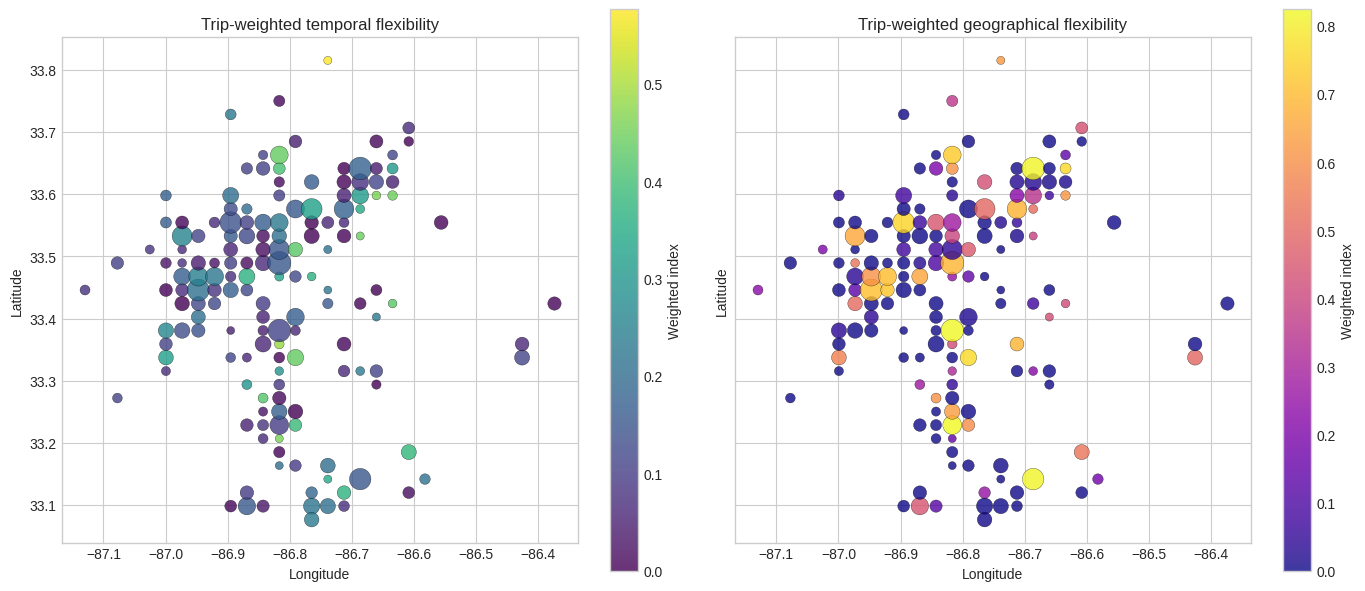

,origin_zone,scored_segments,scored_trips,outcome_trips,cancelled_trips,temporal_weighted_mean,geographical_weighted_mean,weighted_cancellation_rate,row,col,longitude_center,latitude_center
91,r28_c16,7,4213,4170,1871,0.1559,0.6899,44.9%,28,16,-86.8169,33.4894
144,r35_c21,6,3735,3714,1503,0.1780,0.8135,40.5%,35,21,-86.6866,33.6415
53,r23_c16,7,3657,3532,997,0.1140,0.8200,28.2%,23,16,-86.8169,33.3807
69,r26_c11,5,3282,3179,1114,0.2113,0.7109,35.0%,26,11,-86.9472,33.4459
112,r31_c13,9,3046,2985,1630,0.1405,0.7523,54.6%,31,13,-86.8951,33.5546
11,r12_c21,5,2967,2964,1574,0.1544,0.8131,53.1%,12,21,-86.6866,33.1415
124,r32_c18,5,2619,2558,1046,0.3230,0.4998,40.9%,32,18,-86.7648,33.5763
97,r29_c16,10,2255,1902,654,0.1551,0.0468,34.4%,29,16,-86.8169,33.5111
101,r30_c10,7,2198,2178,440,0.2602,0.6556,20.2%,30,10,-86.9732,33.5328
125,r32_c20,8,2030,2007,818,0.1800,0.6840,40.8%,32,20,-86.7127,33.5763


In [11]:
scored_grid = scored.assign(
    temporal_weighted_total=(
        scored["trips"] * scored["temporal_flexibility_index"]
    ),
    geographical_weighted_total=(
        scored["trips"] * scored["geographical_flexibility_index"]
    ),
)
origin_grid = (
    scored_grid.groupby("origin_zone", observed=True)
    .agg(
        scored_segments=("segment_id", "size"),
        scored_trips=("trips", "sum"),
        temporal_weighted_total=("temporal_weighted_total", "sum"),
        geographical_weighted_total=("geographical_weighted_total", "sum"),
        outcome_trips=("outcome_trips", "sum"),
        cancelled_trips=("cancelled_trips", "sum"),
    )
    .reset_index()
)
origin_grid["temporal_weighted_mean"] = (
    origin_grid["temporal_weighted_total"] / origin_grid["scored_trips"]
)
origin_grid["geographical_weighted_mean"] = (
    origin_grid["geographical_weighted_total"] / origin_grid["scored_trips"]
)
origin_grid["weighted_cancellation_rate"] = (
    origin_grid["cancelled_trips"] / origin_grid["outcome_trips"]
)
origin_grid = origin_grid.drop(columns=[
    "temporal_weighted_total", "geographical_weighted_total"
])
zone_parts = origin_grid["origin_zone"].str.extract(r"r(?P<row>-?\d+)_c(?P<col>-?\d+)").astype(int)
origin_grid = pd.concat([origin_grid, zone_parts], axis=1)
origin_grid["longitude_center"] = metadata["longitude_origin"] + (origin_grid["col"] + 0.5) * metadata["longitude_step"]
origin_grid["latitude_center"] = metadata["latitude_origin"] + (origin_grid["row"] + 0.5) * metadata["latitude_step"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, column, title, cmap in [
    (axes[0], "temporal_weighted_mean", "Trip-weighted temporal flexibility", "viridis"),
    (axes[1], "geographical_weighted_mean", "Trip-weighted geographical flexibility", "plasma"),
]:
    sizes = 20 + 260 * np.sqrt(origin_grid["scored_trips"] / origin_grid["scored_trips"].max())
    points = ax.scatter(
        origin_grid["longitude_center"], origin_grid["latitude_center"],
        c=origin_grid[column], s=sizes, cmap=cmap, alpha=0.8,
        edgecolor="black", linewidth=0.25,
    )
    ax.set(title=title, xlabel="Longitude", ylabel="Latitude", aspect="equal")
    fig.colorbar(points, ax=ax, label="Weighted index")
plt.tight_layout()
plt.show()

display(origin_grid.nlargest(15, "scored_trips").style.format({
    "temporal_weighted_mean": "{:.4f}", "geographical_weighted_mean": "{:.4f}",
    "weighted_cancellation_rate": "{:.1%}",
    "longitude_center": "{:.4f}", "latitude_center": "{:.4f}",
}))


## 8. Segments for operational interpretation

The tables below retain the two indices separately. `temporal_demand_opportunity`
and `geographical_demand_opportunity` multiply the relevant index by historical
trip volume. Completion and cancellation do not enter either opportunity measure.


In [12]:
scored["temporal_demand_opportunity"] = scored["trips"] * scored["temporal_flexibility_index"]
scored["geographical_demand_opportunity"] = scored["trips"] * scored["geographical_flexibility_index"]

interpretation_columns = [
    "segment_id", "Purpose", "origin_zone", "weekday", "trips",
    "temporal_flexibility_index", "geographical_flexibility_index",
    "temporal_demand_opportunity", "geographical_demand_opportunity",
    "completion_rate", "cancellation_rate", "flexibility_type",
]
print("Highest temporal demand opportunity")
display(scored.nlargest(15, "temporal_demand_opportunity")[interpretation_columns])
print("Highest geographical demand opportunity")
display(scored.nlargest(15, "geographical_demand_opportunity")[interpretation_columns])


Highest temporal demand opportunity


,segment_id,Purpose,origin_zone,weekday,trips,temporal_flexibility_index,geographical_flexibility_index,temporal_demand_opportunity,geographical_demand_opportunity,completion_rate,cancellation_rate,flexibility_type
2099,Nutrition | r27_c14 | Wednesday,Nutrition,r27_c14,Wednesday,813,0.364699,0.651710,296.50,529.840098,0.453875,0.546125,Higher temporal flexibility / Destination dive...
236,Dialysis | r36_c16 | Friday,Dialysis,r36_c16,Friday,454,0.441079,0.722845,200.25,328.171806,0.545657,0.454343,Higher temporal flexibility / Destination dive...
239,Dialysis | r36_c16 | Wednesday,Dialysis,r36_c16,Wednesday,425,0.438235,0.728172,186.25,309.472941,0.589499,0.410501,Higher temporal flexibility / Destination dive...
237,Dialysis | r36_c16 | Monday,Dialysis,r36_c16,Monday,415,0.433735,0.743318,180.00,308.477108,0.595642,0.404358,Higher temporal flexibility / Destination dive...
2270,Nutrition | r32_c18 | Friday,Nutrition,r32_c18,Friday,527,0.329222,0.502259,173.50,264.690702,0.610136,0.389864,Higher temporal flexibility / Destination dive...
2273,Nutrition | r32_c18 | Tuesday,Nutrition,r32_c18,Tuesday,530,0.326887,0.498975,173.25,264.456604,0.624277,0.375723,Higher temporal flexibility / Destination dive...
2272,Nutrition | r32_c18 | Thursday,Nutrition,r32_c18,Thursday,546,0.311355,0.498283,170.00,272.062271,0.608614,0.391386,Higher temporal flexibility / Destination dive...
2271,Nutrition | r32_c18 | Monday,Nutrition,r32_c18,Monday,512,0.324219,0.499878,166.00,255.937500,0.500998,0.499002,Higher temporal flexibility / Destination dive...
2274,Nutrition | r32_c18 | Wednesday,Nutrition,r32_c18,Wednesday,504,0.323909,0.499496,163.25,251.746032,0.608961,0.391039,Higher temporal flexibility / Destination dive...
2057,Nutrition | r26_c11 | Thursday,Nutrition,r26_c11,Thursday,736,0.207541,0.736956,152.75,542.399457,0.610335,0.389665,Higher temporal flexibility / Destination dive...


Highest geographical demand opportunity


,segment_id,Purpose,origin_zone,weekday,trips,temporal_flexibility_index,geographical_flexibility_index,temporal_demand_opportunity,geographical_demand_opportunity,completion_rate,cancellation_rate,flexibility_type
1997,Nutrition | r23_c16 | Thursday,Nutrition,r23_c16,Thursday,822,0.116788,0.848639,96.00,697.581509,0.755,0.245,Lower temporal flexibility / Destination diver...
2131,Nutrition | r28_c16 | Wednesday,Nutrition,r28_c16,Wednesday,974,0.155287,0.664703,151.25,647.420945,0.586279,0.413721,Higher temporal flexibility / Destination dive...
2320,Nutrition | r35_c21 | Friday,Nutrition,r35_c21,Friday,782,0.181586,0.813146,142.00,635.879795,0.561381,0.438619,Higher temporal flexibility / Destination dive...
1995,Nutrition | r23_c16 | Friday,Nutrition,r23_c16,Friday,757,0.130779,0.831678,99.00,629.579921,0.652235,0.347765,Higher temporal flexibility / Destination dive...
2321,Nutrition | r35_c21 | Monday,Nutrition,r35_c21,Monday,762,0.160105,0.817272,122.00,622.761155,0.53245,0.46755,Higher temporal flexibility / Destination dive...
2323,Nutrition | r35_c21 | Tuesday,Nutrition,r35_c21,Tuesday,744,0.175067,0.826678,130.25,615.048387,0.621438,0.378562,Higher temporal flexibility / Destination dive...
2324,Nutrition | r35_c21 | Wednesday,Nutrition,r35_c21,Wednesday,745,0.181208,0.811423,135.00,604.510067,0.65457,0.34543,Higher temporal flexibility / Destination dive...
2128,Nutrition | r28_c16 | Monday,Nutrition,r28_c16,Monday,848,0.156250,0.693218,132.50,587.849057,0.525565,0.474435,Higher temporal flexibility / Destination dive...
2127,Nutrition | r28_c16 | Friday,Nutrition,r28_c16,Friday,755,0.117881,0.768079,89.00,579.899338,0.508021,0.491979,Lower temporal flexibility / Destination diver...
1996,Nutrition | r23_c16 | Monday,Nutrition,r23_c16,Monday,693,0.099206,0.831448,68.75,576.193362,0.703148,0.296852,Lower temporal flexibility / Destination diver...


## 9. Save the characterization tables

The exported segment table supports later filtering and follow-up analysis. It
contains outcomes for description, but no outcome field is used to construct
either flexibility index or either demand-opportunity measure.


In [13]:
SEGMENT_OUTPUT = PROJECT_DIR / "two_index_characterization_segments.csv"
ORIGIN_OUTPUT = PROJECT_DIR / "two_index_characterization_origin_grids.csv"

scored.sort_values(["Purpose", "origin_zone", "weekday"]).to_csv(SEGMENT_OUTPUT, index=False)
origin_grid.sort_values("scored_trips", ascending=False).to_csv(ORIGIN_OUTPUT, index=False)

print(f"Saved: {SEGMENT_OUTPUT.name}")
print(f"Saved: {ORIGIN_OUTPUT.name}")


Saved: two_index_characterization_segments.csv
Saved: two_index_characterization_origin_grids.csv


## Interpretation guardrails and next step

1. These indices summarize observed historical distributions; they do not prove
   that an individual rider will accept a proposed time or destination change.
2. Same-period outcome associations can reflect purpose, weekday, demand volume,
   service conditions, or cancellation mechanisms. They are not causal effects.
3. Completion and cancellation are complements when the denominator contains only
   those two statuses, so their correlations mirror one another.
4. A later validation can estimate flexibility from an earlier period and examine
   outcomes in a later period. That temporal validation is intentionally outside
   the scope of this contemporaneous notebook.
